In [ ]:
# =============================================================================
# CELL 1: Import all required libraries
# =============================================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import butter, filtfilt, find_peaks
import os

In [ ]:
# =============================================================================
# CELL 2: Upload CSV file from your PC
# =============================================================================

def upload_file():
    """
    Handles file upload in different environments (Colab, Jupyter, local Python)
    """
    # Check if running in Google Colab
    try:
        from google.colab import files
        print("Google Colab detected. Please upload your CSV file.")
        uploaded = files.upload()
        filename = list(uploaded.keys())[0]
        return filename
    except ImportError:
        # Not in Colab, use local file dialog or manual entry
        print("Not in Google Colab. Please provide file path.")

        # Try using tkinter for file dialog (if available)
        try:
            import tkinter as tk
            from tkinter import filedialog
            root = tk.Tk()
            root.withdraw()
            filename = filedialog.askopenfilename(
                title="Select your insole CSV file",
                filetypes=[("CSV files", "*.csv"), ("All files", "*.*")]
            )
            root.destroy()
            if filename:
                print("Selected file: " + filename)
                return filename
        except:
            pass

        # Fallback: manual entry
        filename = input("Enter the full path to your CSV file: ").strip()
        return filename

print("=" * 60)
print("WEARABLE INSOLE GAIT ANALYSIS WITH SLIP RISK SCORING")
print("=" * 60)

csv_filename = upload_file()
print("")
print("File selected: " + csv_filename)

In [ ]:
# =============================================================================
# CELL 3: Load the CSV file and display its contents
# =============================================================================

print("Loading file: " + csv_filename)

try:
    data = pd.read_csv(csv_filename)
    print("File loaded successfully")
    print("Shape: " + str(data.shape[0]) + " rows, " + str(data.shape[1]) + " columns")
    print("")
    print("Column names found:")
    for i, col in enumerate(data.columns):
        print("  " + str(i+1) + ". " + str(col))
    print("")
    print("First 5 rows of data:")
    print(data.head())
except Exception as e:
    print("ERROR: Could not load file - " + str(e))
    raise

Loading file: 09-RTSOCS - 2022.10.18-11.57.53.csv
File loaded successfully
Shape: 4464 rows, 21 columns

Column names found:
  1. insole
  2. foot
  3. timestamp
  4. seq
  5. acx
  6. acy
  7. acz
  8. gyrx
  9. gyry
  10. gyrz
  11. p_toe_1_f
  12. p_toe_1_b
  13. p_toe_3
  14. p_toe_5
  15. p_arc_i
  16. p_arc_o
  17. p_heel_i
  18. p_heel_o
  19. roll
  20. pitch
  21. yaw

First 5 rows of data:
                    insole  foot     timestamp  seq    acx    acy    acz  \
0  00:3B:13:12:01:3D:4B:F1  left  1.666087e+09    1 -0.562 -0.208  0.835   
1  00:3B:13:12:01:3D:4B:F1  left  1.666087e+09    2 -0.569 -0.209  0.838   
2  00:3B:13:12:01:3D:4B:F1  left  1.666087e+09    3 -0.577 -0.197  0.854   
3  00:3B:13:12:01:3D:4B:F1  left  1.666087e+09    4 -0.588 -0.214  0.834   
4  00:3B:13:12:01:3D:4B:F1  left  1.666087e+09    5 -0.612 -0.213  0.800   

   gyrx  gyry  gyrz  ...  p_toe_1_b  p_toe_3  p_toe_5  p_arc_i  p_arc_o  \
0   0.0   6.1   2.1  ...          0        0        0        0   

In [ ]:
# =============================================================================
# CELL 4: Automatically detect timestamp, pitch, and pressure columns
# =============================================================================

print("Auto-detecting columns...")

# Convert all column names to lowercase for matching
cols_lower = [str(col).lower() for col in data.columns]

# Detect timestamp column
timestamp_col = None
for i, col in enumerate(data.columns):
    col_lower = str(col).lower()
    if 'timestamp' in col_lower or 'time' in col_lower or 't(s)' in col_lower:
        timestamp_col = col
        break

# Detect pitch column
pitch_col = None
for i, col in enumerate(data.columns):
    col_lower = str(col).lower()
    if 'pitch' in col_lower:
        pitch_col = col
        break

# Detect pressure/heel columns
pressure_cols = []
for i, col in enumerate(data.columns):
    col_lower = str(col).lower()
    if 'p_heel' in col_lower or 'heel' in col_lower or 'pressure' in col_lower:
        pressure_cols.append(col)

# If no specific heel columns found, look for any pressure-like columns
if len(pressure_cols) == 0:
    for i, col in enumerate(data.columns):
        col_lower = str(col).lower()
        if 'press' in col_lower or 'force' in col_lower:
            pressure_cols.append(col)

# Extract data based on detected columns
if timestamp_col is None:
    print("WARNING: No timestamp column found. Using row index as time.")
    time = np.arange(len(data)) / 100.0
else:
    time = data[timestamp_col].values.astype(float)
    print("Timestamp column detected: " + timestamp_col)

if pitch_col is None:
    print("WARNING: No pitch column found. Using zeros for pitch.")
    pitch = np.zeros(len(data))
else:
    pitch = data[pitch_col].values.astype(float)
    print("Pitch column detected: " + pitch_col)

if len(pressure_cols) == 0:
    print("ERROR: No pressure/heel column found.")
    print("Your columns: " + str(list(data.columns)))
    raise ValueError("Missing pressure column")
else:
    heel_pressure = np.zeros(len(data))
    for col in pressure_cols:
        heel_pressure += data[col].values.astype(float)
    print("Pressure column(s) detected: " + str(pressure_cols))

print("")
print("Data summary:")
print("  Time range: " + str(time.min()) + " to " + str(time.max()))
print("  Pitch range: " + str(round(pitch.min(), 2)) + " to " + str(round(pitch.max(), 2)))
print("  Pressure range: " + str(round(heel_pressure.min(), 2)) + " to " + str(round(heel_pressure.max(), 2)))

Auto-detecting columns...
Timestamp column detected: timestamp
Pitch column detected: pitch
Pressure column(s) detected: ['p_heel_i', 'p_heel_o']

Data summary:
  Time range: 1666087026.05651 to 1666087071.28922
  Pitch range: -55.47 to 64.84
  Pressure range: 0.0 to 6426.0


In [ ]:
# =============================================================================
# CELL 5: Convert timestamp to relative seconds
# =============================================================================

# Check if timestamp looks like milliseconds (large numbers)
if timestamp_col is not None and len(time) > 1:
    if np.mean(np.diff(time)) > 10:
        print("Detected millisecond timestamps. Converting to seconds...")
        time = (time - time[0]) / 1000.0
    else:
        time = (time - time[0])
        if np.mean(np.diff(time)) > 10:
            time = time / 1000.0
else:
    time = (time - time[0]) / 1000.0 if time[0] != 0 else time

print("Time converted to seconds. Range: " + str(round(time.min(), 2)) + " to " + str(round(time.max(), 2)) + " seconds")

Time converted to seconds. Range: 0.0 to 45.23 seconds


In [ ]:
# =============================================================================
# CELL 6: Low-pass filter the signals (FIXED)
# =============================================================================

def butter_lowpass(signal, cutoff, fs, order=4):
    # Handle invalid fs or cutoff
    if fs <= 0 or np.isnan(fs):
        fs = 100.0
    if cutoff <= 0:
        cutoff = 10.0

    nyq = 0.5 * fs
    # Ensure normal_cutoff is between 0 and 1
    normal_cutoff = cutoff / nyq

    # Clamp to valid range
    if normal_cutoff >= 1:
        normal_cutoff = 0.99
    if normal_cutoff <= 0:
        normal_cutoff = 0.01

    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    return filtfilt(b, a, signal)

# Estimate sampling rate
time_diff = np.diff(time)
valid_diffs = time_diff[time_diff > 0]

if len(valid_diffs) > 0:
    fs = 1.0 / np.mean(valid_diffs)
    print("Estimated sampling frequency: " + str(round(fs, 1)) + " Hz")
else:
    fs = 100.0
    print("Warning: Could not compute fs reliably -> using fallback 100 Hz")

# Check if fs is valid
if fs <= 0 or np.isnan(fs):
    fs = 100.0
    print("Fixed sampling rate to: " + str(fs) + " Hz")

# Apply filters with safe cutoffs
pitch_cutoff = min(6, fs/2.1)  # Ensure cutoff < fs/2
pressure_cutoff = min(25, fs/2.1)

print("Pitch filter cutoff: " + str(round(pitch_cutoff, 2)) + " Hz")
print("Pressure filter cutoff: " + str(round(pressure_cutoff, 2)) + " Hz")

pitch_filtered = butter_lowpass(pitch, cutoff=pitch_cutoff, fs=fs)
heel_filtered = butter_lowpass(heel_pressure, cutoff=pressure_cutoff, fs=fs)

print("Signals filtered successfully")

Estimated sampling frequency: 49.9 Hz
Pitch filter cutoff: 6 Hz
Pressure filter cutoff: 23.75 Hz
Signals filtered successfully


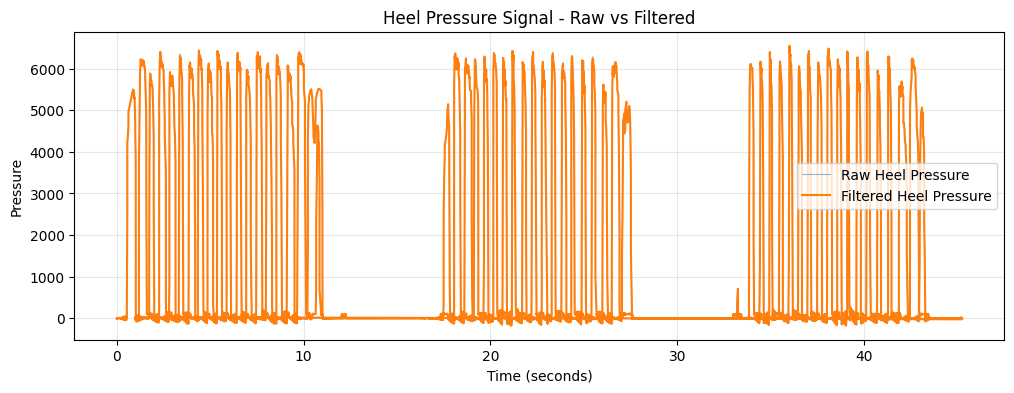

In [ ]:
# =============================================================================
# CELL 7: Visualize raw vs filtered heel pressure
# =============================================================================

plt.figure(figsize=(12, 4))
plt.plot(time, heel_pressure, label='Raw Heel Pressure', alpha=0.5, linewidth=0.8)
plt.plot(time, heel_filtered, label='Filtered Heel Pressure', linewidth=1.5)
plt.title("Heel Pressure Signal - Raw vs Filtered")
plt.xlabel("Time (seconds)")
plt.ylabel("Pressure")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [28]:
# =============================================================================
# CELL 8: Heel Strike Detection - IMPROVED SENSITIVE VERSION
# =============================================================================

# Use multiple thresholds to find optimal detection
thresholds_to_try = [0.10, 0.12, 0.15, 0.20]
best_peaks = []
best_threshold = 0.15

for thresh in thresholds_to_try:
    test_threshold = thresh * np.max(heel_filtered)
    test_peaks, _ = find_peaks(
        heel_filtered,
        distance=max(int(fs * 0.3), 8),
        height=test_threshold,
        prominence=0.05 * np.std(heel_filtered)
    )
    if len(test_peaks) > len(best_peaks):
        best_peaks = test_peaks
        best_threshold = thresh

peaks = best_peaks.astype(int)
threshold = best_threshold * np.max(heel_filtered)

print("Heel Strikes Detected: " + str(len(peaks)))
print("Optimal threshold used: " + str(best_threshold) + " of max pressure")
print("")
print("First 20 heel strike times:")
for i, p in enumerate(peaks[:20]):
    if p < len(time):
        print("  " + str(i+1) + ": " + str(round(time[p], 2)) + " seconds")

Heel Strikes Detected: 59
Optimal threshold used: 0.1 of max pressure

First 20 heel strike times:
  1: 0.87 seconds
  2: 1.8 seconds
  3: 2.85 seconds
  4: 3.93 seconds
  5: 4.92 seconds
  6: 5.94 seconds
  7: 6.96 seconds
  8: 8.1 seconds
  9: 9.15 seconds
  10: 10.41 seconds
  11: 10.86 seconds
  12: 17.73 seconds
  13: 18.69 seconds
  14: 19.68 seconds
  15: 20.68 seconds
  16: 21.72 seconds
  17: 22.8 seconds
  18: 23.88 seconds
  19: 24.91 seconds
  20: 26.04 seconds


In [29]:
# =============================================================================
# CELL 9: Toe-Off (TO) detection
# =============================================================================

toe_offs = []

if len(peaks) > 1:
    for i in range(len(peaks)-1):
        segment = heel_filtered[peaks[i]:peaks[i+1]]
        if len(segment) > 5:
            # Find minimum pressure between heel strikes
            min_idx = np.argmin(segment) + peaks[i]

            # Also check pitch maximum if pitch data is available
            if pitch_col is not None and len(pitch_filtered) > peaks[i+1]:
                pitch_segment = pitch_filtered[peaks[i]:peaks[i+1]]
                if len(pitch_segment) > 5:
                    pitch_max_idx = np.argmax(pitch_segment) + peaks[i]
                    if abs(min_idx - pitch_max_idx) < 20:
                        min_idx = int((min_idx + pitch_max_idx) / 2)

            toe_offs.append(min_idx)

toe_offs = np.array(toe_offs, dtype=int)

print("Toe-Offs Detected: " + str(len(toe_offs)))

Toe-Offs Detected: 58


In [ ]:
# =============================================================================
# CELL 10: Gait Phase estimation (0-100 percent of cycle) - FIXED VERSION
# =============================================================================

phase = np.zeros_like(time)

if len(peaks) > 1:
    for i in range(len(peaks)-1):
        start = peaks[i]
        end = peaks[i+1]
        if end > start:
            # Create linear progression from 0 to 100 between heel strikes
            phase[start:end] = np.linspace(0, 100, end - start)

    # After the last heel strike, extend the last phase value
    if len(peaks) > 0 and peaks[-1] < len(time):
        phase[peaks[-1]:] = 100

    print("Gait phase estimated for " + str(len(peaks)-1) + " gait cycles")
    print("Phase range: " + str(round(np.min(phase), 1)) + " to " + str(round(np.max(phase), 1)))

else:
    print("Insufficient heel strikes for gait phase estimation")
    print("Setting phase to zeros")
    phase = np.zeros_like(time)

# Verify phase values are correct
print("First 20 phase values:")
print(phase[:20])
print("")
print("Unique phase values (first 10):")
unique_phase = np.unique(phase[:500])
print(unique_phase[:10])

Gait phase estimated for 57 gait cycles
Phase range: 0.0 to 100.0
First 20 phase values:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]

Unique phase values (first 10):
[0.         1.63934426 1.85185185 1.88679245 1.92307692 2.
 2.04081633 2.22222222 3.27868852 3.7037037 ]


In [ ]:
# =============================================================================
# CELL 11: Calculate cadence and stride time variability
# =============================================================================

if len(peaks) > 1:
    stride_times = np.diff(time[peaks])
    stride_times = stride_times[stride_times > 0]
    if len(stride_times) > 0:
        mean_stride = np.mean(stride_times)
        cadence = 60.0 / mean_stride if mean_stride > 0 else np.nan
        stride_variability = np.std(stride_times) if len(stride_times) > 1 else np.nan
    else:
        cadence = np.nan
        stride_variability = np.nan
else:
    cadence = np.nan
    stride_variability = np.nan

print("")
print("===== Basic Gait Metrics =====")
print("Cadence (steps/min): " + (str(round(cadence, 1)) if not np.isnan(cadence) else "N/A"))
print("Stride time variability (s): " + (str(round(stride_variability, 3)) if not np.isnan(stride_variability) else "N/A"))


===== Basic Gait Metrics =====
Cadence (steps/min): 40.2
Stride time variability (s): 1.578


In [27]:
# =============================================================================
# CELL 12: Calculate Slip Risk Scores - IMPROVED WITH BETTER HEEL STRIKE HANDLING
# =============================================================================

print("")
print("===== Slip Risk Score Analysis =====")

slip_risk_scores = []
step_metrics_list = []

# Ensure peaks and toe_offs are valid
if len(peaks) < 2:
    print("Insufficient heel strikes detected: " + str(len(peaks)))
    print("Need at least 2 heel strikes for gait analysis.")
    print("Try lowering the threshold in CELL 8.")

elif len(toe_offs) == 0:
    print("No toe-offs detected. Cannot calculate slip risk without toe-offs.")
    print("Check your toe-off detection in CELL 9.")

else:
    # Align peaks and toe_offs to have same length
    min_length = min(len(peaks)-1, len(toe_offs))

    if min_length == 0:
        print("No complete gait cycles found.")
    else:
        num_steps = min_length
        print("Processing " + str(num_steps) + " gait cycles...")
        print("")

        # First, collect all raw values to determine proper scaling
        all_impact_slopes = []
        all_flat_durations = []
        all_pitch_at_hs = []
        all_pushoff_changes = []
        all_heel_pressures = []

        for i in range(num_steps):
            hs_idx = peaks[i]
            to_idx = toe_offs[i]

            if to_idx <= hs_idx:
                continue

            # Impact slope (rate of pressure increase at heel strike)
            window_start = max(0, hs_idx - 5)
            impact_slope = heel_filtered[hs_idx] - heel_filtered[window_start]
            all_impact_slopes.append(impact_slope)

            # Foot flat duration
            foot_flat_duration = time[to_idx] - time[hs_idx]
            all_flat_durations.append(foot_flat_duration)

            # Peak heel pressure
            peak_pressure = heel_filtered[hs_idx]
            all_heel_pressures.append(peak_pressure)

            # Pitch at heel strike
            if pitch_col is not None and len(pitch_filtered) > hs_idx:
                pitch_at_hs = abs(pitch_filtered[hs_idx])
                all_pitch_at_hs.append(pitch_at_hs)

            # Push-off change (pitch velocity at toe-off)
            if pitch_col is not None and to_idx + 10 < len(pitch_filtered):
                pitch_before = pitch_filtered[to_idx]
                pitch_after = pitch_filtered[min(to_idx+10, len(pitch_filtered)-1)]
                pushoff_change = abs(pitch_after - pitch_before)
                all_pushoff_changes.append(pushoff_change)

        # Calculate adaptive thresholds using percentiles
        if len(all_impact_slopes) > 0:
            impact_dangerous = np.percentile(all_impact_slopes, 75)
            impact_safe = np.percentile(all_impact_slopes, 25)
        else:
            impact_dangerous = 100
            impact_safe = 20

        if len(all_flat_durations) > 0:
            duration_normal = np.percentile(all_flat_durations, 25)
            duration_dangerous = np.percentile(all_flat_durations, 75)
        else:
            duration_normal = 0.4
            duration_dangerous = 0.6

        if len(all_pitch_at_hs) > 0:
            pitch_dangerous = np.percentile(all_pitch_at_hs, 75)
            pitch_safe = np.percentile(all_pitch_at_hs, 25)
        else:
            pitch_dangerous = 10
            pitch_safe = 3

        if len(all_pushoff_changes) > 0:
            pushoff_dangerous = np.percentile(all_pushoff_changes, 75)
            pushoff_safe = np.percentile(all_pushoff_changes, 25)
        else:
            pushoff_dangerous = 15
            pushoff_safe = 5

        print("Adaptive thresholds based on this data:")
        print("  Impact - Safe: <" + str(round(impact_safe, 2)) + "  Dangerous: >" + str(round(impact_dangerous, 2)))
        print("  Foot flat duration - Safe: >" + str(round(duration_normal, 3)) + "s  Dangerous: <" + str(round(duration_dangerous, 3)) + "s")
        print("  Pitch at heel strike - Safe: <" + str(round(pitch_safe, 2)) + "  Dangerous: >" + str(round(pitch_dangerous, 2)))
        print("  Push-off change - Safe: <" + str(round(pushoff_safe, 2)) + "  Dangerous: >" + str(round(pushoff_dangerous, 2)))
        print("")

        # Calculate risk scores for each step
        for i in range(num_steps):
            hs_idx = peaks[i]
            to_idx = toe_offs[i]

            if to_idx <= hs_idx:
                continue

            # Metric 1: Impact risk (higher slope = higher risk)
            impact_slope = heel_filtered[hs_idx] - heel_filtered[max(0, hs_idx-5)]
            if impact_dangerous > impact_safe:
                if impact_slope <= impact_safe:
                    impact_risk = 0
                elif impact_slope >= impact_dangerous:
                    impact_risk = 100
                else:
                    impact_risk = ((impact_slope - impact_safe) / (impact_dangerous - impact_safe)) * 100
            else:
                impact_risk = min(100, (impact_slope / max(impact_dangerous, 1)) * 100)

            # Metric 2: Duration risk (shorter duration = higher risk)
            foot_flat_duration = time[to_idx] - time[hs_idx]
            if duration_dangerous > duration_normal:
                if foot_flat_duration >= duration_normal:
                    duration_risk = 0
                elif foot_flat_duration <= duration_dangerous:
                    duration_risk = 100
                else:
                    duration_risk = ((duration_normal - foot_flat_duration) / (duration_normal - duration_dangerous)) * 100
            else:
                if foot_flat_duration < 0.4:
                    duration_risk = min(100, (0.4 - foot_flat_duration) * 250)
                else:
                    duration_risk = 0

            # Metric 3: Pitch risk (higher pitch = higher risk)
            if pitch_col is not None and len(all_pitch_at_hs) > 0:
                pitch_at_hs = abs(pitch_filtered[hs_idx])
                if pitch_dangerous > pitch_safe:
                    if pitch_at_hs <= pitch_safe:
                        pitch_risk = 0
                    elif pitch_at_hs >= pitch_dangerous:
                        pitch_risk = 100
                    else:
                        pitch_risk = ((pitch_at_hs - pitch_safe) / (pitch_dangerous - pitch_safe)) * 100
                else:
                    pitch_risk = min(100, (pitch_at_hs / max(pitch_dangerous, 1)) * 100)
            else:
                pitch_risk = 0

            # Metric 4: Push-off risk (larger change = higher risk)
            if pitch_col is not None and len(all_pushoff_changes) > 0 and to_idx + 10 < len(pitch_filtered):
                pitch_before = pitch_filtered[to_idx]
                pitch_after = pitch_filtered[min(to_idx+10, len(pitch_filtered)-1)]
                pushoff_change = abs(pitch_after - pitch_before)
                if pushoff_dangerous > pushoff_safe:
                    if pushoff_change <= pushoff_safe:
                        pushoff_risk = 0
                    elif pushoff_change >= pushoff_dangerous:
                        pushoff_risk = 100
                    else:
                        pushoff_risk = ((pushoff_change - pushoff_safe) / (pushoff_dangerous - pushoff_safe)) * 100
                else:
                    pushoff_risk = min(100, (pushoff_change / max(pushoff_dangerous, 1)) * 100)
            else:
                pushoff_risk = 0

            # Weighted combination
            WEIGHT_IMPACT = 0.35
            WEIGHT_DURATION = 0.35
            WEIGHT_PITCH = 0.15
            WEIGHT_PUSHOFF = 0.15

            # Adjust weights if pitch data is missing
            if pitch_col is None:
                WEIGHT_IMPACT = 0.50
                WEIGHT_DURATION = 0.50
                WEIGHT_PITCH = 0
                WEIGHT_PUSHOFF = 0

            final_risk = (WEIGHT_IMPACT * impact_risk +
                          WEIGHT_DURATION * duration_risk +
                          WEIGHT_PITCH * pitch_risk +
                          WEIGHT_PUSHOFF * pushoff_risk)

            # Ensure risk is between 0 and 100
            final_risk = min(100, max(0, final_risk))

            slip_risk_scores.append(final_risk)
            step_metrics_list.append({
                'step_number': i + 1,
                'time_at_step': time[hs_idx],
                'impact_risk': round(impact_risk, 1),
                'duration_risk': round(duration_risk, 1),
                'pitch_risk': round(pitch_risk, 1),
                'pushoff_risk': round(pushoff_risk, 1),
                'final_slip_risk': round(final_risk, 1)
            })

        # Print summary
        if len(slip_risk_scores) > 0:
            print("")
            print("===== RESULTS =====")
            print("Total steps analyzed: " + str(len(slip_risk_scores)))
            print("Average slip risk score: " + str(round(np.mean(slip_risk_scores), 1)) + "/100")
            print("Maximum slip risk score: " + str(round(np.max(slip_risk_scores), 1)) + "/100")
            print("Minimum slip risk score: " + str(round(np.min(slip_risk_scores), 1)) + "/100")
            print("Standard deviation: " + str(round(np.std(slip_risk_scores), 2)))

            low_risk = sum(1 for s in slip_risk_scores if s < 30)
            moderate_risk = sum(1 for s in slip_risk_scores if 30 <= s < 60)
            high_risk = sum(1 for s in slip_risk_scores if s >= 60)

            print("")
            print("Risk Level Distribution:")
            print("  Low risk (0-30): " + str(low_risk) + " steps (" + str(int(100*low_risk/len(slip_risk_scores))) + "%)")
            print("  Moderate risk (30-60): " + str(moderate_risk) + " steps (" + str(int(100*moderate_risk/len(slip_risk_scores))) + "%)")
            print("  High risk (60-100): " + str(high_risk) + " steps (" + str(int(100*high_risk/len(slip_risk_scores))) + "%)")

            print("")
            print("First 15 step risk scores:")
            for m in step_metrics_list[:15]:
                # Create a simple bar visualization
                if m['final_slip_risk'] < 30:
                    bar_color = "G"
                elif m['final_slip_risk'] < 60:
                    bar_color = "Y"
                else:
                    bar_color = "R"
                bar = bar_color + "=" * int(m['final_slip_risk'] / 5)
                print("  Step " + str(m['step_number']).ljust(3) + ": " +
                      str(m['final_slip_risk']).rjust(5) + "/100 " + bar)

            # Identify highest risk steps
            print("")
            print("Highest risk steps:")
            sorted_steps = sorted(step_metrics_list, key=lambda x: x['final_slip_risk'], reverse=True)
            for m in sorted_steps[:3]:
                print("  Step " + str(m['step_number']) + ": " + str(m['final_slip_risk']) + "/100")


===== Slip Risk Score Analysis =====
Processing 57 gait cycles...

Adaptive thresholds based on this data:
  Impact - Safe: <6063.46  Dangerous: >6458.41
  Foot flat duration - Safe: >0.87s  Dangerous: <0.959s
  Pitch at heel strike - Safe: <3.82  Dangerous: >10.37
  Push-off change - Safe: <18.34  Dangerous: >51.05


===== RESULTS =====
Total steps analyzed: 57
Average slip risk score: 42.5/100
Maximum slip risk score: 80.9/100
Minimum slip risk score: 4.4/100
Standard deviation: 18.25

Risk Level Distribution:
  Low risk (0-30): 14 steps (24%)
  Moderate risk (30-60): 36 steps (63%)
  High risk (60-100): 7 steps (12%)

First 15 step risk scores:
  Step 1  :  35.0/100 Y=======
  Step 2  :  13.5/100 G==
  Step 3  :  15.0/100 G===
  Step 4  :  31.0/100 Y======
  Step 5  :  56.4/100 Y===========
  Step 6  :  41.2/100 Y========
  Step 7  :  21.6/100 G====
  Step 8  :  22.3/100 G====
  Step 9  :  54.3/100 Y==========
  Step 10 :  50.0/100 Y==========
  Step 11 :  15.0/100 G===
  Step 12 :

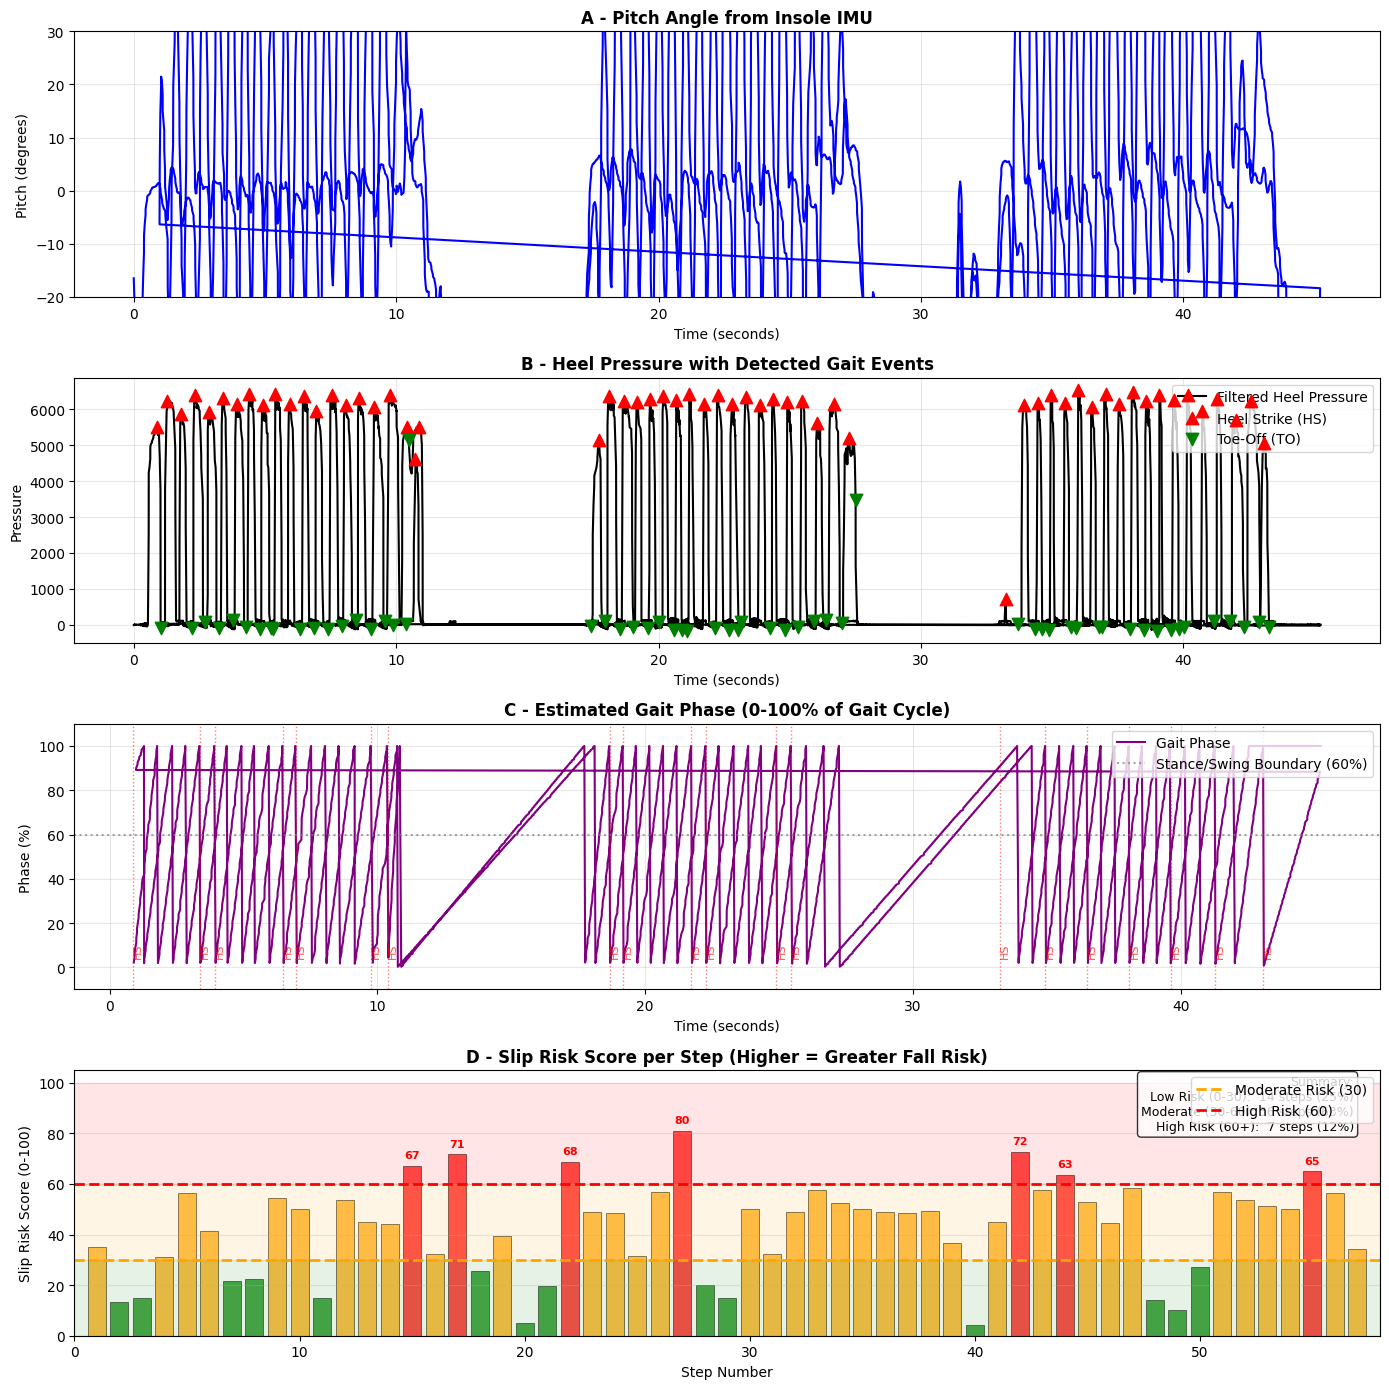

In [30]:
# =============================================================================
# CELL 13: IMPROVED VISUALIZATION - FIXED GAIT PHASE PLOT
# =============================================================================

plt.figure(figsize=(14, 14))

# Subplot 1: Filtered Pitch Angle
plt.subplot(4, 1, 1)
plt.plot(time, pitch_filtered, color='blue', linewidth=1.5)
plt.title('A - Pitch Angle from Insole IMU', fontsize=12, fontweight='bold')
plt.xlabel('Time (seconds)', fontsize=10)
plt.ylabel('Pitch (degrees)', fontsize=10)
plt.grid(True, alpha=0.3)
plt.ylim([-20, 30])

# Subplot 2: Heel Pressure with Gait Events
plt.subplot(4, 1, 2)
plt.plot(time, heel_filtered, color='black', linewidth=1.5, label='Filtered Heel Pressure')
if len(peaks) > 0:
    plt.scatter(time[peaks], heel_filtered[peaks], color='red', s=80,
                marker='^', label='Heel Strike (HS)', zorder=10)
if len(toe_offs) > 0:
    plt.scatter(time[toe_offs], heel_filtered[toe_offs], color='green', s=80,
                marker='v', label='Toe-Off (TO)', zorder=10)
plt.title('B - Heel Pressure with Detected Gait Events', fontsize=12, fontweight='bold')
plt.xlabel('Time (seconds)', fontsize=10)
plt.ylabel('Pressure', fontsize=10)
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)

# Subplot 3: Estimated Gait Phase - FIXED VERSION
plt.subplot(4, 1, 3)
# Plot only non-zero phase values to see the pattern clearly
mask = phase > 0
if np.sum(mask) > 0:
    plt.plot(time[mask], phase[mask], color='purple', linewidth=1.5, label='Gait Phase')
else:
    plt.plot(time, phase, color='purple', linewidth=1.5, label='Gait Phase')

# Add heel strike markers on phase plot to show resets
if len(peaks) > 0:
    for peak in peaks[::3]:  # Show every 3rd heel strike to avoid clutter
        if peak < len(time):
            plt.axvline(x=time[peak], color='red', linestyle=':', alpha=0.5, linewidth=1)
            plt.text(time[peak], 5, 'HS', rotation=90, fontsize=8, color='red', alpha=0.7)

plt.title('C - Estimated Gait Phase (0-100% of Gait Cycle)', fontsize=12, fontweight='bold')
plt.xlabel('Time (seconds)', fontsize=10)
plt.ylabel('Phase (%)', fontsize=10)
plt.ylim(-10, 110)
plt.grid(True, alpha=0.3)
plt.axhline(y=60, color='gray', linestyle=':', linewidth=1.5, alpha=0.7, label='Stance/Swing Boundary (60%)')
plt.legend(loc='upper right')

# Subplot 4: Slip Risk Score
plt.subplot(4, 1, 4)

if len(step_metrics_list) > 0:
    step_numbers = [m['step_number'] for m in step_metrics_list]
    step_risks = [m['final_slip_risk'] for m in step_metrics_list]

    # Create color-coded bars based on risk level
    colors = []
    for risk in step_risks:
        if risk < 30:
            colors.append('green')
        elif risk < 60:
            colors.append('orange')
        else:
            colors.append('red')

    # Plot as bar chart
    plt.bar(step_numbers, step_risks, color=colors, alpha=0.7, width=0.8, edgecolor='black', linewidth=0.5)

    # Add threshold lines
    plt.axhline(y=30, color='orange', linestyle='--', linewidth=2, label='Moderate Risk (30)')
    plt.axhline(y=60, color='red', linestyle='--', linewidth=2, label='High Risk (60)')

    # Add risk labels on high risk bars
    for step, risk in zip(step_numbers, step_risks):
        if risk >= 60:
            plt.text(step, risk + 3, str(int(risk)), ha='center', fontsize=8, fontweight='bold', color='red')

    plt.title('D - Slip Risk Score per Step (Higher = Greater Fall Risk)', fontsize=12, fontweight='bold')
    plt.xlabel('Step Number', fontsize=10)
    plt.ylabel('Slip Risk Score (0-100)', fontsize=10)
    plt.ylim(0, 105)
    plt.xlim(0, max(step_numbers) + 1)
    plt.legend(loc='upper right')
    plt.grid(True, alpha=0.3, axis='y')

    # Add risk level background zones
    plt.axhspan(0, 30, alpha=0.1, color='green')
    plt.axhspan(30, 60, alpha=0.1, color='orange')
    plt.axhspan(60, 100, alpha=0.1, color='red')

    # Add summary statistics text box
    low_count = sum(1 for r in step_risks if r < 30)
    mod_count = sum(1 for r in step_risks if 30 <= r < 60)
    high_count = sum(1 for r in step_risks if r >= 60)
    total = len(step_risks)

    if total > 0:
        summary_text = (
            f"Summary:\n"
            f"Low Risk (0-30):  {low_count} steps ({100*low_count/total:.0f}%)\n"
            f"Moderate (30-60): {mod_count} steps ({100*mod_count/total:.0f}%)\n"
            f"High Risk (60+):  {high_count} steps ({100*high_count/total:.0f}%)"
        )
        plt.gca().text(0.98, 0.98, summary_text,
                       transform=plt.gca().transAxes,
                       fontsize=9,
                       verticalalignment='top',
                       horizontalalignment='right',
                       bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

else:
    plt.text(0.5, 0.5, "Insufficient data for slip risk analysis",
             ha='center', va='center', transform=plt.gca().transAxes)
    plt.title('D - Slip Risk Score Analysis', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()